# Kickstarter — Full Pipeline
**Data Preparation → Classification**

This notebook:
1. Loads and merges the raw Kickstarter CSV with category data
2. Computes `reached` and `status` labels
3. Preprocesses descriptions (lowercasing, tokenisation, stopwords, lemmatisation)
4. Removes globally rare / common tokens and category-specific stopwords
5. Trains 4 classifiers per category with 5-fold stratified CV
6. Reports metrics, confusion matrices, and top predictive tokens

## 0 · Dependencies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import nltk
from nltk.corpus import stopwords
import string
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
from collections import Counter
import ast
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
    print('XGBoost available.')
except ImportError:
    print('XGBoost not found — install with: pip install xgboost')
    XGBOOST_AVAILABLE = False

try:
    import shap
    SHAP_AVAILABLE = True
    print('SHAP available.')
except ImportError:
    print('SHAP not found — install with: pip install shap')
    SHAP_AVAILABLE = False

# Download required NLTK resources (safe to re-run)
for resource in ['punkt', 'stopwords', 'wordnet', 'averaged_perceptron_tagger', 'punkt_tab', 'averaged_perceptron_tagger_eng']:
    nltk.download(resource, quiet=True)

SEED     = 42
CV_FOLDS = 5
CATEGORIES = ['Technology', 'Games', 'Music', 'Publishing', 'Film & Video']

XGBoost available.
SHAP available.


## 1 · Load raw data and add categories

In [3]:
# ── Load the main campaigns CSV ───────────────────────────────────────────────
campaigns = pd.read_csv('raw_kickstarter.csv', index_col=0)
print(f'Loaded {len(campaigns):,} campaigns.')
campaigns.head()

Loaded 7,354 campaigns.


,url,title,description,pledged,usd_pledged,converted_pledged_amount,goal,currency
0,https://www.kickstarter.com/projects/thetruthb...,NaN,The PROBLEM: So much entertainment today pushe...,71123.0,71123.0,61607,48000.0,USD
1,https://www.kickstarter.com/projects/99625582/...,NaN,Millions of American college students have stu...,65318.0,65318.0,56579,61500.0,USD
2,https://www.kickstarter.com/projects/distortre...,Cartoon Network Alphabet Pins,Full A-Z Set I'm launching this set to show my...,462.0,462.0,400,8000.0,USD
3,https://www.kickstarter.com/projects/jordym/th...,The Balloon - a short film,"On a sleepy summer afternoon, we stared into t...",5137.0,5137.0,4449,15000.0,USD
4,https://www.kickstarter.com/projects/trans-mov...,NaN,48 hours of pledge matching! Amazing news! Two...,50640.0,50640.0,43865,50000.0,USD


In [4]:
# ── Load category snapshots and build url → category mapping ─────────────────
folder_path = 'Kickstarter_2026-03-12T03_20_26_556Z'
files = glob.glob(f'{folder_path}/*.csv')
print(f'Number of snapshot files found: {len(files)}')

dfs = []
for file in files:
    print(f'  Loading: {file}')
    df_temp = pd.read_csv(file)
    dfs.append(df_temp)

df_snapshots = pd.concat(dfs, ignore_index=True)

url_to_category = {}
for _, row in df_snapshots.iterrows():
    parsed = ast.literal_eval(row['category'])
    parent_name = parsed.get('parent_name') or parsed.get('name')
    url_parsed = ast.literal_eval(row['urls'])
    project_url = url_parsed['web']['project']
    url_to_category[project_url] = parent_name

campaigns['category'] = campaigns['url'].map(url_to_category)

print(f'\nMatched: {campaigns["category"].notna().sum()} / {len(campaigns)}')
print(campaigns['category'].value_counts())

Number of snapshot files found: 85
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter001.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter002.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter003.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter004.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter005.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter006.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter007.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter008.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter009.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter010.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter011.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter012.csv
  Loading: Kickstarter_2026-03-12T03_20_26_556Z\Kickstarter013.csv
  Loading: Kickstarter_2026-03

## 2 · Compute `reached` and `status` labels

In [5]:
campaigns['reached'] = (campaigns['pledged'] / campaigns['goal']) * 100
campaigns['status']  = campaigns['reached'].apply(lambda x: 1 if x >= 100 else 0)

print(f"Success rate: {campaigns['status'].mean():.1%}")
campaigns[['goal', 'pledged', 'reached', 'status']].describe()

Success rate: 61.3%


,goal,pledged,reached,status
count,7354.000000,7.354000e+03,7354.000000,7354.000000
mean,24875.763575,4.735351e+04,235.719597,0.613272
std,43025.123371,2.384215e+05,1136.093211,0.487034
min,5001.000000,6.600000e+01,0.200000,0.000000
25%,9400.000000,3.152500e+03,15.993333,0.000000
50%,13000.000000,1.039750e+04,102.688478,1.000000
75%,25000.000000,2.439625e+04,125.818125,1.000000
max,1000000.000000,8.243797e+06,41290.950000,1.000000


## 3 · Text preprocessing

Steps:
- Lowercase, remove URLs, keep only alphanumeric characters
- Tokenise with NLTK word_tokenize
- Remove English stopwords and single/double-character tokens
- POS tagging → WordNet lemmatisation

In [6]:
def preprocess(text):
    """Lowercase, strip URLs, keep alphanumeric, tokenise, remove stopwords."""
    text   = text.lower()
    text   = re.sub(r'http\S+|www\S+', ' ', text)
    text_p = ''.join([char for char in text if char.isalnum() or char.isspace()])
    words  = word_tokenize(text_p)
    sw     = set(stopwords.words('english'))
    words  = [w for w in words if w not in sw and len(w) > 2 and w.isalpha()]
    return words

print('Preprocessing descriptions...')
campaigns['description_processed'] = campaigns['description'].apply(preprocess)
print('Done.')

Preprocessing descriptions...
Done.


In [7]:
# ── POS tagging + lemmatisation ───────────────────────────────────────────────
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'): return 'a'
    if treebank_tag.startswith('V'): return 'v'
    if treebank_tag.startswith('N'): return 'n'
    if treebank_tag.startswith('R'): return 'r'
    return 'n'

print('POS tagging...')
campaigns['pos_tagged'] = campaigns['description_processed'].apply(nltk.pos_tag)

print('Lemmatising...')
campaigns['lemmatized'] = campaigns['pos_tagged'].apply(
    lambda tagged: [
        lemmatizer.lemmatize(word, get_wordnet_pos(pos))
        for word, pos in tagged
    ]
)

initial_vocab = set(token for doc in campaigns['lemmatized'] for token in doc)
print(f'Initial vocabulary size: {len(initial_vocab):,} tokens')

POS tagging...
Lemmatising...
Initial vocabulary size: 110,954 tokens


## 4 · Global frequency filter

Remove tokens that are **too rare** (appear in fewer than 10 documents) or **too common** (appear in more than 55% of documents).

In [8]:
docs = campaigns['lemmatized']
N    = len(docs)

# Document frequency table
df_counter = Counter()
for doc in docs:
    df_counter.update(set(doc))

df_table = pd.DataFrame({
    'word':     list(df_counter.keys()),
    'doc_freq': list(df_counter.values())
})
df_table['doc_freq_ratio'] = df_table['doc_freq'] / N
df_table = df_table.sort_values('doc_freq_ratio', ascending=False)

print(f'Total unique tokens: {len(df_table):,}')
df_table.head(20)

Total unique tokens: 110,954


,word,doc_freq,doc_freq_ratio
88,make,6131,0.833696
172,help,5236,0.711993
375,one,5194,0.706282
526,work,5178,0.704107
216,time,5136,0.698395
370,get,4955,0.673783
275,project,4770,0.648627
448,need,4738,0.644275
799,new,4721,0.641964
227,like,4711,0.640604


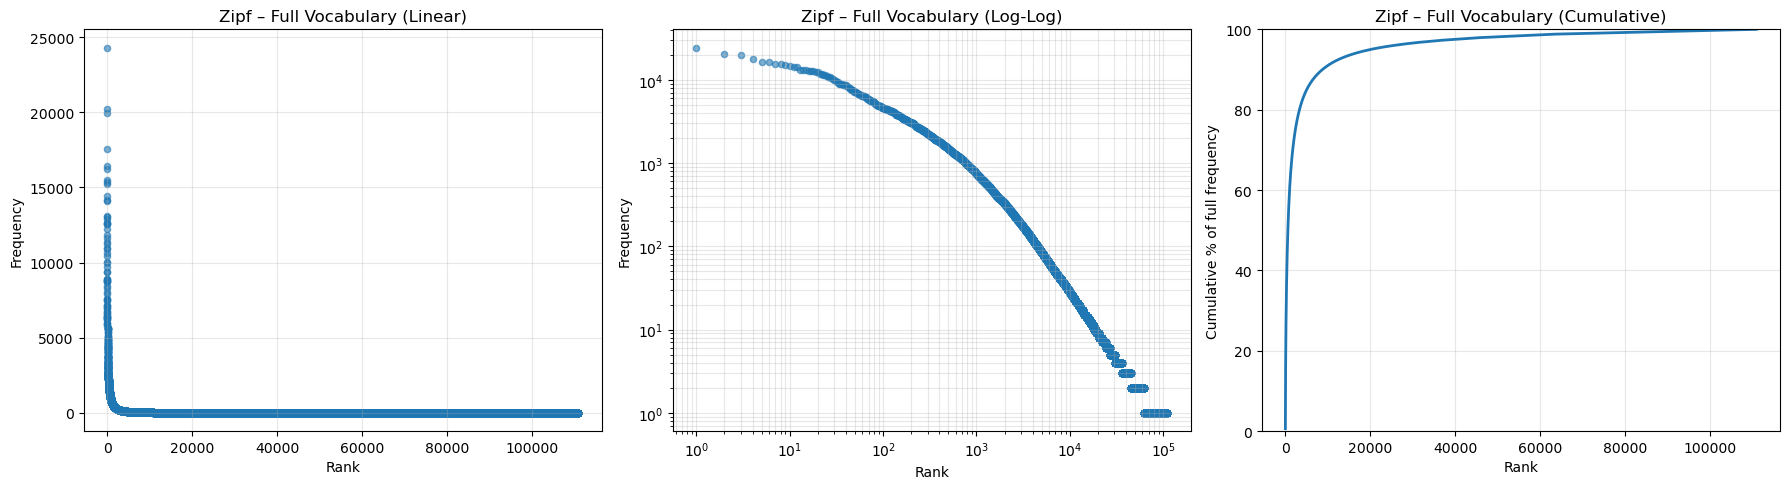

In [9]:
# ── Zipf's law visualisation ──────────────────────────────────────────────────
term_freq_counter = Counter()
for doc in campaigns['lemmatized']:
    term_freq_counter.update(doc)

zipf_df = pd.DataFrame({
    'word':      list(term_freq_counter.keys()),
    'frequency': list(term_freq_counter.values())
}).sort_values('frequency', ascending=False).reset_index(drop=True)

zipf_df['rank']       = range(1, len(zipf_df) + 1)
zipf_df['cumsum_freq'] = zipf_df['frequency'].cumsum()
zipf_df['cumsum_pct']  = 100 * zipf_df['cumsum_freq'] / zipf_df['frequency'].sum()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[0].set(xlabel='Rank', ylabel='Frequency', title='Zipf – Full Vocabulary (Linear)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(zipf_df['rank'], zipf_df['frequency'], alpha=0.6, s=20)
axes[1].set(xlabel='Rank', ylabel='Frequency', title='Zipf – Full Vocabulary (Log-Log)',
            xscale='log', yscale='log')
axes[1].grid(True, alpha=0.3, which='both')

axes[2].plot(zipf_df['rank'], zipf_df['cumsum_pct'], linewidth=2)
axes[2].set(xlabel='Rank', ylabel='Cumulative % of full frequency',
            title='Zipf – Full Vocabulary (Cumulative)', ylim=(0, 100))
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ── Apply global thresholds ───────────────────────────────────────────────────
min_doc_count = 10          # tokens appearing in fewer docs are too rare
top_n_words   = 250         # top-N by doc_freq_ratio treated as generic stopwords
min_ratio     = min_doc_count / N

top_words_preview = (
    df_table
    .sort_values('doc_freq_ratio', ascending=False)
    .head(top_n_words)
)

vocab       = set(df_table['word'])
rare_words  = set(df_table['word'][df_table['doc_freq_ratio'] <= min_ratio])
common_words = set(top_words_preview['word'])
vocab       = vocab - common_words - rare_words

print(f'Common words removed : {len(common_words):,}')
print(f'Rare words removed   : {len(rare_words):,}')
print(f'Vocabulary size now  : {len(vocab):,} tokens')

Common words removed : 250
Rare words removed   : 97,057
Vocabulary size now  : 13,647 tokens


In [11]:
# Apply global vocab filter
campaigns['description_processed'] = campaigns['lemmatized'].apply(
    lambda doc: [w for w in doc if w in vocab]
)
campaigns = campaigns.drop(columns=['lemmatized'])
df = campaigns.copy()

## 5 · Category-specific stopword removal

For each category, the top 50 most frequent tokens (by document frequency) are considered too generic and are removed.

In [12]:
selected_categories  = ['Technology', 'Games', 'Music', 'Publishing', 'Film & Video']
top_n_words_cat      = 50
category_high_freq_words = {}

for category_name in selected_categories:
    category_df = df[df['category'] == category_name].copy()
    cat_docs    = category_df['description_processed']

    cat_counter = Counter()
    for doc in cat_docs:
        cat_counter.update(set(doc))

    cat_table = pd.DataFrame({
        'word':     list(cat_counter.keys()),
        'doc_freq': list(cat_counter.values())
    })
    cat_table['doc_freq_ratio'] = cat_table['doc_freq'] / len(cat_docs)
    high_freq = cat_table.sort_values('doc_freq_ratio', ascending=False).head(top_n_words_cat)

    category_high_freq_words[category_name] = high_freq
    print(f'\n{category_name}')
    display(high_freq)


Technology


,word,doc_freq,doc_freq_ratio
1,technology,701,0.470786
195,user,667,0.447952
171,control,630,0.423103
311,test,620,0.416387
108,device,611,0.410343
143,tool,604,0.405641
235,app,533,0.357958
306,simple,533,0.357958
137,prototype,514,0.345198
121,connect,508,0.341169



Games


,word,doc_freq,doc_freq_ratio
744,player,864,0.607595
309,card,557,0.391702
827,gameplay,507,0.356540
418,shipping,479,0.336850
480,version,477,0.335443
1047,tier,475,0.334037
541,adventure,475,0.334037
344,detail,462,0.324895
134,box,458,0.322082
1298,rule,455,0.319972



Music


,word,doc_freq,doc_freq_ratio
226,album,895,0.734811
105,song,877,0.720033
46,musician,624,0.512315
142,master,564,0.463054
88,mix,508,0.417077
461,band,471,0.386700
147,track,402,0.330049
113,hear,396,0.325123
8,perform,389,0.319376
21,musical,350,0.287356



Publishing


,word,doc_freq,doc_freq_ratio
131,author,512,0.421746
6,publish,497,0.409390
793,copy,474,0.390445
58,reader,420,0.345964
1027,edition,372,0.306425
389,writer,359,0.295717
903,beautiful,345,0.284185
505,note,309,0.254530
707,sign,303,0.249588
1501,child,303,0.249588



Film & Video


,word,doc_freq,doc_freq_ratio
186,crew,959,0.476877
634,festival,896,0.445549
249,cast,883,0.439085
137,movie,825,0.410244
205,budget,746,0.370960
1154,actor,736,0.365987
589,filmmaker,733,0.364495
501,screen,714,0.355047
331,location,707,0.351566
1515,shoot,696,0.346096


In [13]:
category_stopwords_all = set()
for category_name, high_freq in category_high_freq_words.items():
    cat_words = high_freq['word'].tolist()
    category_stopwords_all.update(cat_words)
    print(f'{category_name} ({len(cat_words)} words): {cat_words}')

print(f'\nTotal unique category stopwords: {len(category_stopwords_all)}')

Technology (50 words): ['technology', 'user', 'control', 'test', 'device', 'tool', 'app', 'simple', 'prototype', 'connect', 'solution', 'require', 'access', 'market', 'ensure', 'platform', 'perfect', 'easily', 'software', 'size', 'browser', 'problem', 'fit', 'improve', 'option', 'battery', 'capable', 'material', 'hour', 'simply', 'range', 'fully', 'custom', 'version', 'result', 'charge', 'multiple', 'track', 'standard', 'data', 'model', 'phone', 'low', 'deliver', 'today', 'single', 'information', 'component', 'hardware', 'whether']
Games (50 words): ['player', 'card', 'gameplay', 'shipping', 'version', 'tier', 'adventure', 'detail', 'box', 'rule', 'item', 'option', 'custom', 'note', 'point', 'style', 'action', 'ensure', 'table', 'unlock', 'collect', 'charge', 'perfect', 'simple', 'ability', 'extra', 'physical', 'creator', 'price', 'multiple', 'choice', 'expand', 'line', 'test', 'deliver', 'core', 'access', 'face', 'craft', 'board', 'form', 'addons', 'fully', 'favorite', 'hour', 'skill'

In [14]:
# Apply category stopwords
vocab = vocab - category_stopwords_all
print(f'Final vocabulary size: {len(vocab):,} tokens')

df['description_processed'] = df['description_processed'].apply(
    lambda doc: [w for w in doc if w in vocab]
)

# Save the processed dataset (optional)
df.to_csv('Kickstarter_processed.csv')
print('Saved: Kickstarter_processed.csv')

Final vocabulary size: 13,440 tokens
Saved: Kickstarter_processed.csv


## 6 · Description-length feature (EDA)

Quick sanity check: does description length differ between successful and failed campaigns?

Raw character length:
         count         mean          std    min      25%     50%      75%  \
status                                                                      
0       2844.0  5074.642405  4257.167629  808.0  2265.75  3808.0  6477.25   
1       4510.0  6292.490022  4746.412752  802.0  2902.25  4999.5  8255.00   

            max  
status           
0       35273.0  
1       35269.0  

Token count after preprocessing:
         count        mean         std   min     25%    50%    75%     max
status                                                                    
0       2844.0  227.444444  203.585347  22.0   92.00  169.0  288.0  1737.0
1       4510.0  279.568736  228.963328  12.0  115.25  213.0  375.0  1733.0


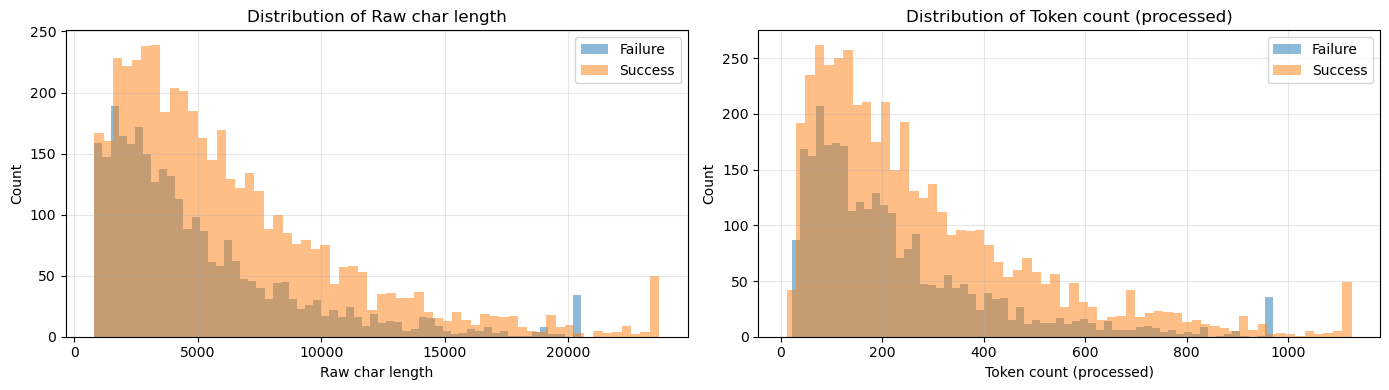

In [15]:
df['desc_len_raw']       = df['description'].str.len()
df['desc_len_tokens']    = df['description_processed'].apply(len)

print('Raw character length:')
print(df.groupby('status')['desc_len_raw'].describe())
print('\nToken count after preprocessing:')
print(df.groupby('status')['desc_len_tokens'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, label in zip(axes,
                          ['desc_len_raw', 'desc_len_tokens'],
                          ['Raw char length', 'Token count (processed)']):
    for status, grp in df.groupby('status'):
        ax.hist(grp[col].clip(upper=grp[col].quantile(0.99)),
                bins=60, alpha=0.5,
                label='Success' if status == 1 else 'Failure')
    ax.set(xlabel=label, ylabel='Count', title=f'Distribution of {label}')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7 · Build text field for classifiers

In [16]:
# Join tokens back into a space-separated string (input for TF-IDF)
df['text'] = df['description_processed'].apply(lambda toks: ' '.join(toks))

print('Average tokens per doc after full preprocessing:')
for cat in CATEGORIES:
    avg = df[df['category'] == cat]['description_processed'].apply(len).mean()
    print(f'  {cat}: {avg:.0f}')

Average tokens per doc after full preprocessing:
  Technology: 293
  Games: 353
  Music: 139
  Publishing: 258
  Film & Video: 242


## 8 · Model factory

Four models per category:
1. **Logistic Regression** + TF-IDF  
2. **Bagging (Decision Trees)** + TF-IDF  
3. **XGBoost** + TF-IDF *(if installed)*  
4. **LinearSVC** + TF-IDF  

In [17]:
TFIDF_PARAMS = dict(
    max_features=20_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=1,
)

def build_models(pos_weight=1.0):
    models = {}

    models['LogReg'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(
                      C=1.0, max_iter=1000,
                      class_weight='balanced',
                      solver='lbfgs', random_state=SEED
                  ))
    ])

    models['Bagging'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   BaggingClassifier(
                      estimator=DecisionTreeClassifier(
                          max_depth=10, class_weight='balanced', random_state=SEED
                      ),
                      n_estimators=100, max_samples=0.8, max_features=0.8,
                      random_state=SEED, n_jobs=-1
                  ))
    ])

    if XGBOOST_AVAILABLE:
        models['XGBoost'] = Pipeline([
            ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
            ('clf',   XGBClassifier(
                          n_estimators=300, learning_rate=0.05,
                          max_depth=6, subsample=0.8, colsample_bytree=0.8,
                          scale_pos_weight=pos_weight,
                          eval_metric='logloss',
                          random_state=SEED, n_jobs=-1, verbosity=0
                      ))
        ])

    models['LinearSVC'] = Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   CalibratedClassifierCV(
                      LinearSVC(
                          C=0.5, max_iter=2000,
                          class_weight='balanced', random_state=SEED
                      ),
                      cv=3
                  ))
    ])

    return models

print('Model factory ready.')

Model factory ready.


## 9 · Cross-validated training + model selection

In [18]:
SCORING = ['accuracy', 'f1_weighted', 'precision_weighted', 'recall_weighted', 'roc_auc']

all_results = []
best_models = {}

for category in CATEGORIES:
    cat_df = df[df['category'] == category].dropna(subset=['text', 'status'])
    X = cat_df['text'].values
    y = cat_df['status'].astype(int).values

    n_pos      = y.sum()
    n_neg      = len(y) - n_pos
    pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)

    print(f"\n{'='*62}")
    print(f"  {category}  |  n={len(y)}  |  success={n_pos} ({100*n_pos/len(y):.1f}%)")
    print(f"{'='*62}")

    models    = build_models(pos_weight=pos_weight)
    best_f1   = -1
    best_name = None

    for model_name, pipeline in models.items():
        cv = cross_validate(
            pipeline, X, y,
            cv=skf, scoring=SCORING,
            return_train_score=False, n_jobs=-1
        )

        m_acc  = cv['test_accuracy'].mean()
        m_f1   = cv['test_f1_weighted'].mean()
        s_f1   = cv['test_f1_weighted'].std()
        m_prec = cv['test_precision_weighted'].mean()
        m_rec  = cv['test_recall_weighted'].mean()
        m_auc  = cv['test_roc_auc'].mean()

        flag = ' <-- best so far' if m_f1 > best_f1 else ''
        print(f"  {model_name:<10}  Acc={m_acc:.3f}  F1={m_f1:.3f}±{s_f1:.3f}  "
              f"Prec={m_prec:.3f}  Rec={m_rec:.3f}  AUC={m_auc:.3f}{flag}")

        all_results.append({
            'category':  category,
            'model':     model_name,
            'n_samples': len(y),
            'accuracy':  round(m_acc,  4),
            'f1':        round(m_f1,   4),
            'f1_std':    round(s_f1,   4),
            'precision': round(m_prec, 4),
            'recall':    round(m_rec,  4),
            'roc_auc':   round(m_auc,  4),
        })

        if m_f1 > best_f1:
            best_f1   = m_f1
            best_name = model_name

    winner = build_models(pos_weight=pos_weight)[best_name]
    winner.fit(X, y)
    best_models[category] = {
        'name':       best_name,
        'pipeline':   winner,
        'X':          X,
        'y':          y,
        'pos_weight': pos_weight,
        'skf':        skf,
    }
    print(f"  --> Winner: {best_name}  (F1={best_f1:.3f})")

results_df = pd.DataFrame(all_results)
print('\nTraining complete.')


  Technology  |  n=1489  |  success=692 (46.5%)
  LogReg      Acc=0.767  F1=0.767±0.017  Prec=0.768  Rec=0.767  AUC=0.841 <-- best so far
  Bagging     Acc=0.736  F1=0.734±0.018  Prec=0.738  Rec=0.736  AUC=0.829
  XGBoost     Acc=0.760  F1=0.760±0.019  Prec=0.760  Rec=0.760  AUC=0.845
  LinearSVC   Acc=0.771  F1=0.770±0.024  Prec=0.771  Rec=0.771  AUC=0.849 <-- best so far
  --> Winner: LinearSVC  (F1=0.770)

  Games  |  n=1422  |  success=882 (62.0%)
  LogReg      Acc=0.824  F1=0.824±0.016  Prec=0.827  Rec=0.824  AUC=0.903 <-- best so far
  Bagging     Acc=0.798  F1=0.800±0.010  Prec=0.806  Rec=0.798  AUC=0.882
  XGBoost     Acc=0.820  F1=0.821±0.016  Prec=0.822  Rec=0.820  AUC=0.902
  LinearSVC   Acc=0.845  F1=0.844±0.016  Prec=0.845  Rec=0.845  AUC=0.909 <-- best so far
  --> Winner: LinearSVC  (F1=0.844)

  Music  |  n=1218  |  success=940 (77.2%)
  LogReg      Acc=0.819  F1=0.803±0.016  Prec=0.804  Rec=0.819  AUC=0.833 <-- best so far
  Bagging     Acc=0.782  F1=0.778±0.033  Prec

## 10 · Results summary

In [ ]:
print('FULL CROSS-VALIDATION RESULTS')
display(
    results_df
    .sort_values(['category', 'f1'], ascending=[True, False])
    .reset_index(drop=True)
)

print('\nBEST MODEL PER CATEGORY')
best_summary = (
    results_df
    .sort_values('f1', ascending=False)
    .groupby('category', sort=False)
    .first()
    .reset_index()
    [['category', 'model', 'n_samples', 'accuracy', 'f1', 'f1_std', 'precision', 'recall', 'roc_auc']]
)
display(best_summary)

## 11 · F1 comparison chart

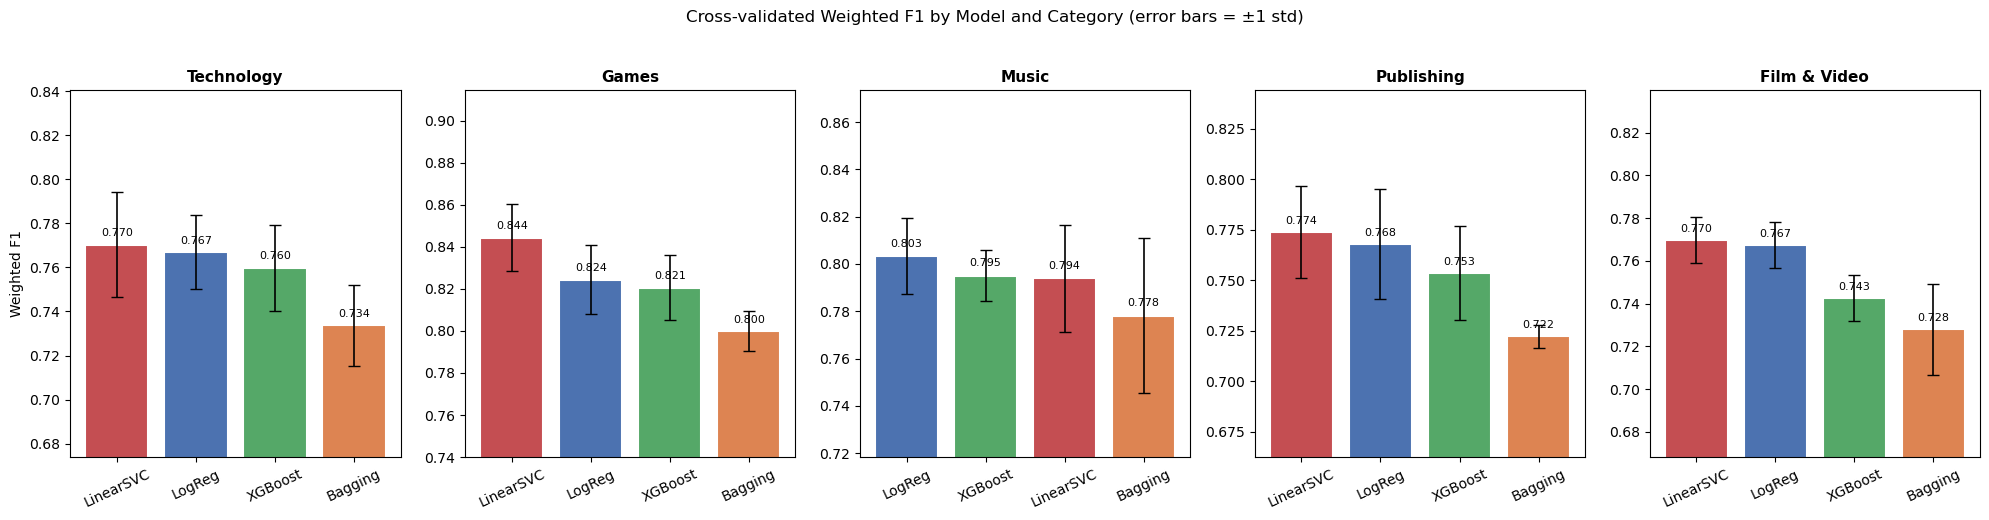

Saved: f1_comparison.png


In [19]:
palette = {
    'LogReg':    '#4C72B0',
    'Bagging':   '#DD8452',
    'XGBoost':   '#55A868',
    'LinearSVC': '#C44E52'
}

fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(20, 5), sharey=False)

for ax, category in zip(axes, CATEGORIES):
    cat_data = (
        results_df[results_df['category'] == category]
        .sort_values('f1', ascending=False)
    )
    colors = [palette.get(m, 'gray') for m in cat_data['model']]
    bars = ax.bar(cat_data['model'], cat_data['f1'],
                  color=colors, edgecolor='white', linewidth=1.5)
    ax.errorbar(
        x=range(len(cat_data)), y=cat_data['f1'], yerr=cat_data['f1_std'],
        fmt='none', color='black', capsize=4, linewidth=1.2
    )
    ax.set_ylim(
        max(0,   cat_data['f1'].min() - 0.06),
        min(1.0, cat_data['f1'].max() + 0.07)
    )
    ax.set_title(category, fontsize=11, fontweight='bold')
    ax.set_ylabel('Weighted F1' if ax == axes[0] else '')
    ax.tick_params(axis='x', rotation=25)
    for bar, val in zip(bars, cat_data['f1']):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8
        )

fig.suptitle(
    'Cross-validated Weighted F1 by Model and Category (error bars = ±1 std)',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: f1_comparison.png')

## 12 · Confusion matrices (out-of-fold predictions)


────────────────────────────────────────────────────
  Technology  -->  Best: LinearSVC
  (out-of-fold predictions, n=1489)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.78      0.80      0.79       797
 Success (1)       0.76      0.73      0.75       692

    accuracy                           0.77      1489
   macro avg       0.77      0.77      0.77      1489
weighted avg       0.77      0.77      0.77      1489



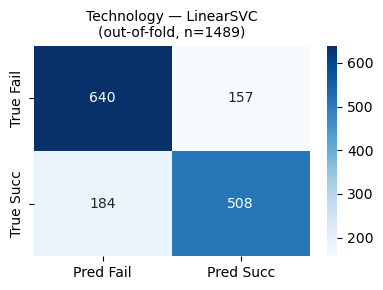


────────────────────────────────────────────────────
  Games  -->  Best: LinearSVC
  (out-of-fold predictions, n=1422)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.81      0.77      0.79       540
 Success (1)       0.86      0.89      0.88       882

    accuracy                           0.85      1422
   macro avg       0.84      0.83      0.83      1422
weighted avg       0.84      0.85      0.84      1422



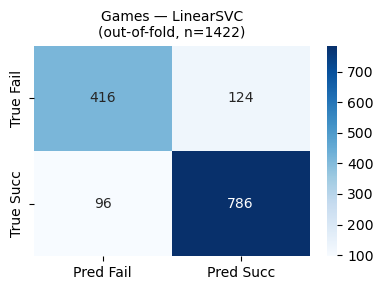


────────────────────────────────────────────────────
  Music  -->  Best: LogReg
  (out-of-fold predictions, n=1218)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.66      0.42      0.52       278
 Success (1)       0.85      0.94      0.89       940

    accuracy                           0.82      1218
   macro avg       0.76      0.68      0.70      1218
weighted avg       0.80      0.82      0.80      1218



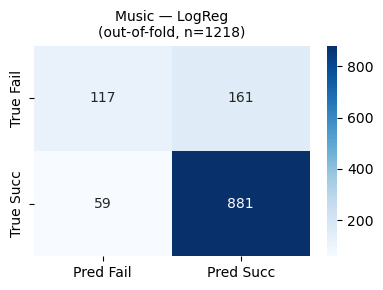


────────────────────────────────────────────────────
  Publishing  -->  Best: LinearSVC
  (out-of-fold predictions, n=1214)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.76      0.65      0.70       487
 Success (1)       0.79      0.86      0.82       727

    accuracy                           0.78      1214
   macro avg       0.77      0.76      0.76      1214
weighted avg       0.78      0.78      0.77      1214



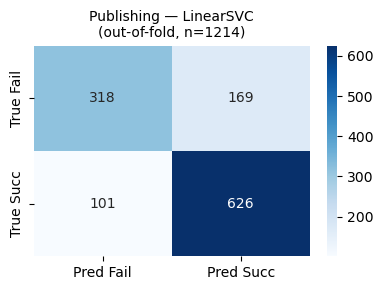


────────────────────────────────────────────────────
  Film & Video  -->  Best: LinearSVC
  (out-of-fold predictions, n=2011)
────────────────────────────────────────────────────
              precision    recall  f1-score   support

 Failure (0)       0.77      0.57      0.66       742
 Success (1)       0.78      0.90      0.84      1269

    accuracy                           0.78      2011
   macro avg       0.77      0.74      0.75      2011
weighted avg       0.78      0.78      0.77      2011



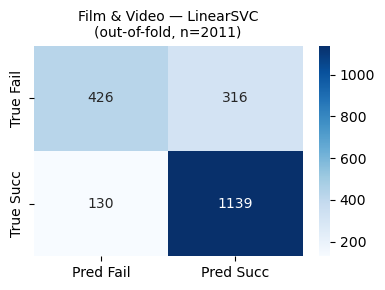

In [20]:
for category in CATEGORIES:
    info       = best_models[category]
    model_name = info['name']
    X          = info['X']
    y          = info['y']
    skf        = info['skf']
    pos_weight = info['pos_weight']

    pipeline   = build_models(pos_weight=pos_weight)[model_name]
    y_pred_oof = cross_val_predict(pipeline, X, y, cv=skf, n_jobs=-1)

    print(f"\n{'─'*52}")
    print(f"  {category}  -->  Best: {model_name}")
    print(f"  (out-of-fold predictions, n={len(y)})")
    print(f"{'─'*52}")
    print(classification_report(y, y_pred_oof, target_names=['Failure (0)', 'Success (1)']))

    cm = confusion_matrix(y, y_pred_oof)
    fig, ax = plt.subplots(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Fail', 'Pred Succ'],
                yticklabels=['True Fail', 'True Succ'])
    ax.set_title(f'{category} — {model_name}\n(out-of-fold, n={len(y)})', fontsize=10)
    plt.tight_layout()
    plt.show()

## 13 · Top 15 predictive tokens per category

In [21]:
N_TOP       = 15
SHAP_SAMPLE = 500

LINEAR_MODELS = ('LogReg', 'LinearSVC')
TREE_MODELS   = ('XGBoost', 'Bagging')

for category in CATEGORIES:
    info       = best_models[category]
    model_name = info['name']
    pipeline   = info['pipeline']
    X          = info['X']
    y          = info['y']

    vectorizer    = pipeline.named_steps['tfidf']
    clf           = pipeline.named_steps['clf']
    feature_names = np.array(vectorizer.get_feature_names_out())

    print(f"\n{'='*52}")
    print(f"  {category}  [{model_name}]")
    print(f"{'='*52}")

    if model_name in LINEAR_MODELS:
        if hasattr(clf, 'calibrated_classifiers_'):
            coef = np.mean(
                [c.estimator.coef_[0] for c in clf.calibrated_classifiers_], axis=0
            )
        else:
            coef = clf.coef_[0]

        top_pos = feature_names[np.argsort(coef)[-N_TOP:][::-1]]
        top_neg = feature_names[np.argsort(coef)[:N_TOP]]

        print(f'  Method: coefficients')
        print(f'  SUCCESS tokens: {list(top_pos)}')
        print(f'  FAILURE tokens: {list(top_neg)}')

    elif model_name in TREE_MODELS:
        if not SHAP_AVAILABLE:
            print(f'  SHAP not installed — skipping {category}.')
            continue

        X_tfidf    = vectorizer.transform(X)
        rng        = np.random.default_rng(SEED)
        n_sample   = min(SHAP_SAMPLE, len(X))
        sample_idx = rng.choice(len(X), size=n_sample, replace=False)
        X_sample   = X_tfidf[sample_idx]

        if model_name == 'XGBoost':
            explainer = shap.TreeExplainer(clf)
            shap_vals = explainer.shap_values(X_sample)
            mean_shap = shap_vals.mean(axis=0)
        elif model_name == 'Bagging':
            background = shap.kmeans(X_sample, k=20)
            explainer  = shap.KernelExplainer(
                lambda x: clf.predict_proba(x)[:, 1], background
            )
            n_explain = min(100, n_sample)
            shap_vals = explainer.shap_values(X_sample[:n_explain], nsamples=100, silent=True)
            mean_shap = shap_vals.mean(axis=0)

        top_pos = feature_names[np.argsort(mean_shap)[-N_TOP:][::-1]]
        top_neg = feature_names[np.argsort(mean_shap)[:N_TOP]]

        print(f'  Method: SHAP (sample n={n_sample if model_name == "XGBoost" else n_explain})')
        print(f'  SUCCESS tokens: {list(top_pos)}')
        print(f'  FAILURE tokens: {list(top_neg)}')


  Technology  [LinearSVC]
  Method: coefficients
  SUCCESS tokens: ['capture', 'promote', 'review', 'recognize', 'crowdfunding', 'found', 'ceo', 'sensor', 'jellop', 'anywhere', 'promote jellop', 'rest', 'partner', 'builtin', 'leg']
  FAILURE tokens: ['site', 'patent', 'similar', 'relationship', 'invention', 'building', 'anyone', 'wearable', 'incorporate', 'portion', 'least', 'operation', 'fashion', 'revolution', 'empower']

  Games  [LinearSVC]
  Method: coefficients
  SUCCESS tokens: ['deck', 'addon', 'click', 'preview', 'manager', 'vat', 'stuff', 'tariff', 'designer', 'bundle', 'scenario', 'import', 'david', 'entire', 'publisher']
  FAILURE tokens: ['mobile', 'replay', 'supporter', 'inventory', 'episode', 'patent', 'entertainment', 'race', 'realize', 'chess', 'magnet', 'street', 'tire', 'round', 'jesus']

  Music  [LogReg]
  Method: coefficients
  SUCCESS tokens: ['ill', 'fall', 'nashville', 'four', 'spend', 'season', 'length', 'tune', 'classical', 'road', 'hire', 'someone', 'fiddle

## 14 · Export results

In [ ]:
results_df.to_csv('classification_results.csv', index=False)
best_summary.to_csv('best_models_summary.csv', index=False)
print('Saved: classification_results.csv  &  best_models_summary.csv')